# 02 — EDA Neon (Star Schema Dimensional)

**Objetivo:** explorar y validar el dataset cargado en NeonDB antes de correr el feature pipeline.

**Fuente:** NeonDB — star schema dimensional  
**Tablas:** `dim_user` (10.000) · `dim_product` (26.686) · `fact_order_products` (1.999.645)  
**Filtros ETL aplicados:** usuarios ≥5 órdenes prior + ≥1 orden train · productos ≥50 compras · eval_set ≠ test · LIMIT 10.000 usuarios · SEED=42

---
**Secciones:**
1. Conexión y carga
2. Validaciones V-1 a V-8 (integridad del ETL)
3. Análisis de `dim_user`
4. Análisis de `dim_product`
5. Análisis de `fact_order_products`
6. Análisis del label (balance de clases)
7. Resumen ejecutivo

## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

# ── Rutas del proyecto ───────────────────────────────────────────
from pathlib import Path
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
LOGS_DIR    = PROJECT_ROOT / 'reports' / 'logs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'FIGURES_DIR  : {FIGURES_DIR}')

# ── Estilo global ─────────────────────────────────────────────────────────────
PALETTE   = 'Blues_d'
C_POS     = '#2196F3'   # label=1
C_NEG     = '#BDBDBD'   # label=0
C_ACCENT  = '#FF5722'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Constantes del ETL ────────────────────────────────────────────────────────
EXPECTED_USERS    = 10_000
EXPECTED_PRODUCTS = 26_686
EXPECTED_FACTS    = 1_999_645
EXPECTED_ORDERS   = 199_750
RANDOM_SEED       = 42

print('Setup OK')

PROJECT_ROOT : C:\Users\feder\Documents\Data_Science\mProyectoFinal\insight-commerce-recsys
FIGURES_DIR  : C:\Users\feder\Documents\Data_Science\mProyectoFinal\insight-commerce-recsys\reports\figures
Setup OK


## 1. Conexión a NeonDB

In [2]:
def get_engine():
    host     = os.getenv('NEON_HOST')
    db       = os.getenv('NEON_DATABASE')
    user     = os.getenv('NEON_USER')
    password = os.getenv('NEON_PASSWORD')
    port     = os.getenv('NEON_PORT', '5432')
    sslmode  = os.getenv('NEON_SSLMODE', 'require')
    url = f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}?sslmode={sslmode}'
    return create_engine(url, pool_pre_ping=True)

engine = get_engine()

# Test de conexión
with engine.connect() as conn:
    result = conn.execute(text('SELECT version()')).fetchone()
    print(f'Conexión OK — PostgreSQL: {result[0][:50]}...')

Conexión OK — PostgreSQL: PostgreSQL 15.16 (ca7a127) on x86_64-pc-linux-gnu,...


In [3]:
# ── Carga de las tres tablas ──────────────────────────────────────────────────
print('Cargando tablas desde NeonDB...')

dim_user    = pd.read_sql('SELECT * FROM dim_user',             engine)
dim_product = pd.read_sql('SELECT * FROM dim_product',          engine)
fact        = pd.read_sql('SELECT * FROM fact_order_products',  engine)

print(f'  dim_user          : {dim_user.shape}')
print(f'  dim_product       : {dim_product.shape}')
print(f'  fact_order_products: {fact.shape}')

Cargando tablas desde NeonDB...
  dim_user          : (10000, 4)
  dim_product       : (26686, 4)
  fact_order_products: (1999645, 10)


## 2. Validaciones V-1 a V-8

In [4]:
# Helper para reportar cada validación
results = {}

def check(name, condition, detail=''):
    status = '✅ PASS' if condition else '❌ FAIL'
    results[name] = condition
    print(f'{status}  {name:45s}  {detail}')

print('=' * 80)
print('VALIDACIONES DE INTEGRIDAD — POST ETL')
print('=' * 80)

# V-1: Conteo de usuarios
n_users = len(dim_user)
check('V-1: dim_user filas = 10.000', n_users == EXPECTED_USERS, f'cargado={n_users:,}')

# V-2: Conteo de productos
n_prod = len(dim_product)
check('V-2: dim_product filas = 26.686', n_prod == EXPECTED_PRODUCTS, f'cargado={n_prod:,}')

# V-3: Conteo de hechos
n_facts = len(fact)
check('V-3: fact_order_products filas = 1.999.645', n_facts == EXPECTED_FACTS, f'cargado={n_facts:,}')

# V-4: Sin eval_set='test' en fact
n_test = (fact['get_eval'] == 'test').sum() if 'get_eval' in fact.columns else 0
check('V-4: Sin registros eval_set=test', n_test == 0, f'test_rows={n_test}')

# V-5: Usuarios en fact presentes en dim_user
users_in_fact  = set(fact['user_key'].unique())
users_in_dim   = set(dim_user['user_key'].unique())
orphan_users   = users_in_fact - users_in_dim
check('V-5: Sin usuarios huérfanos en fact', len(orphan_users) == 0, f'huérfanos={len(orphan_users)}')

# V-6: Productos en fact presentes en dim_product
prods_in_fact  = set(fact['product_key'].unique())
prods_in_dim   = set(dim_product['product_key'].unique())
orphan_prods   = prods_in_fact - prods_in_dim
check('V-6: Sin productos huérfanos en fact', len(orphan_prods) == 0, f'huérfanos={len(orphan_prods)}')

# V-7: Usuarios con prior + train
prior_users    = set(fact[fact['get_eval'] == 'prior']['user_key'].unique())
train_users    = set(fact[fact['get_eval'] == 'train']['user_key'].unique())
users_with_both = prior_users & train_users
check('V-7: Usuarios con prior Y train >= 9.989', len(users_with_both) >= 9_989,
      f'con_ambos={len(users_with_both):,}')

# V-8: Órdenes únicas
n_orders = fact['order_key'].nunique()
check('V-8: Órdenes únicas ≈ 199.750', abs(n_orders - EXPECTED_ORDERS) < 100,
      f'ordenes_unicas={n_orders:,}')

print('=' * 80)
passed = sum(results.values())
print(f'Resultado: {passed}/{len(results)} validaciones OK')

VALIDACIONES DE INTEGRIDAD — POST ETL
✅ PASS  V-1: dim_user filas = 10.000                   cargado=10,000
✅ PASS  V-2: dim_product filas = 26.686                cargado=26,686
✅ PASS  V-3: fact_order_products filas = 1.999.645     cargado=1,999,645
✅ PASS  V-4: Sin registros eval_set=test               test_rows=0
✅ PASS  V-5: Sin usuarios huérfanos en fact            huérfanos=0
✅ PASS  V-6: Sin productos huérfanos en fact           huérfanos=0
✅ PASS  V-7: Usuarios con prior Y train >= 9.989       con_ambos=9,989
✅ PASS  V-8: Órdenes únicas ≈ 199.750                  ordenes_unicas=199,750
Resultado: 8/8 validaciones OK


## 3. Análisis de `dim_user`

In [5]:
print('dim_user — esquema:')
print(dim_user.dtypes)
print(f'\nNulos por columna:')
print(dim_user.isnull().sum())
dim_user.head(3)

dim_user — esquema:
user_key           int64
user_name         object
user_address      object
user_birthdate    object
dtype: object

Nulos por columna:
user_key          0
user_name         0
user_address      0
user_birthdate    0
dtype: int64


,user_key,user_name,user_address,user_birthdate
0,154853,Jason Jackson,"0705 Katie Trace Suite 649, North Connor, MH 0...",1993-04-20
1,154874,Tony Rodriguez,"PSC 7928, Box 4499, APO AE 91857",1995-05-24
2,154899,Olivia Rodriguez,"Unit 6788 Box 1652, DPO AA 58667",1958-05-08


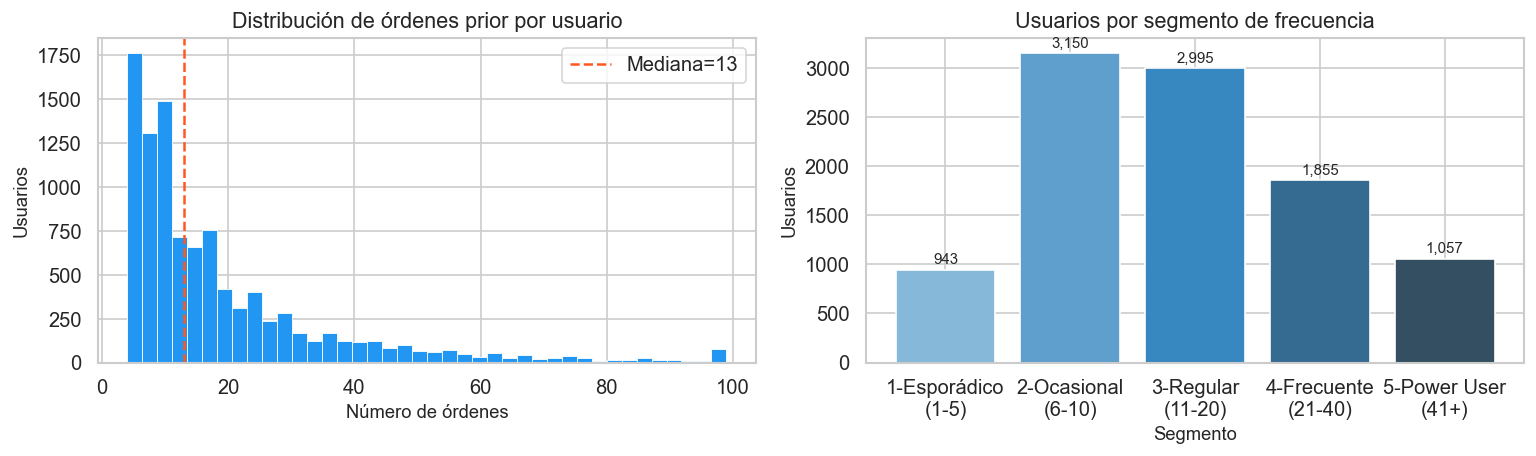


Estadísticas órdenes por usuario (prior):
count    10000.00
mean        18.98
std         17.36
min          4.00
25%          8.00
50%         13.00
75%         23.00
max         99.00
Name: n_orders, dtype: float64


In [6]:
# Órdenes por usuario (prior)
prior = fact[fact['get_eval'] == 'prior'].copy()
train = fact[fact['get_eval'] == 'train'].copy()

orders_per_user = prior.groupby('user_key')['order_key'].nunique().reset_index(name='n_orders')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(orders_per_user['n_orders'], bins=40, color=C_POS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de órdenes prior por usuario')
axes[0].set_xlabel('Número de órdenes')
axes[0].set_ylabel('Usuarios')
axes[0].axvline(orders_per_user['n_orders'].median(), color=C_ACCENT, ls='--', lw=1.5,
                label=f'Mediana={orders_per_user["n_orders"].median():.0f}')
axes[0].legend()

# Segmentos de usuario
SEGMENT_BINS  = [0, 5, 10, 20, 40, 9999]
SEGMENT_NAMES = ['1-Esporádico\n(1-5)', '2-Ocasional\n(6-10)',
                 '3-Regular\n(11-20)', '4-Frecuente\n(21-40)', '5-Power User\n(41+)']
orders_per_user['segment'] = pd.cut(
    orders_per_user['n_orders'], bins=SEGMENT_BINS, labels=SEGMENT_NAMES, right=True
)
seg_counts = orders_per_user['segment'].value_counts().sort_index()
bars = axes[1].bar(seg_counts.index, seg_counts.values,
                    color=sns.color_palette('Blues_d', len(seg_counts)))
axes[1].set_title('Usuarios por segmento de frecuencia')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Usuarios')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_user_orders_segments.png', bbox_inches='tight')
plt.show()

print(f"\nEstadísticas órdenes por usuario (prior):")
print(orders_per_user['n_orders'].describe().round(2))

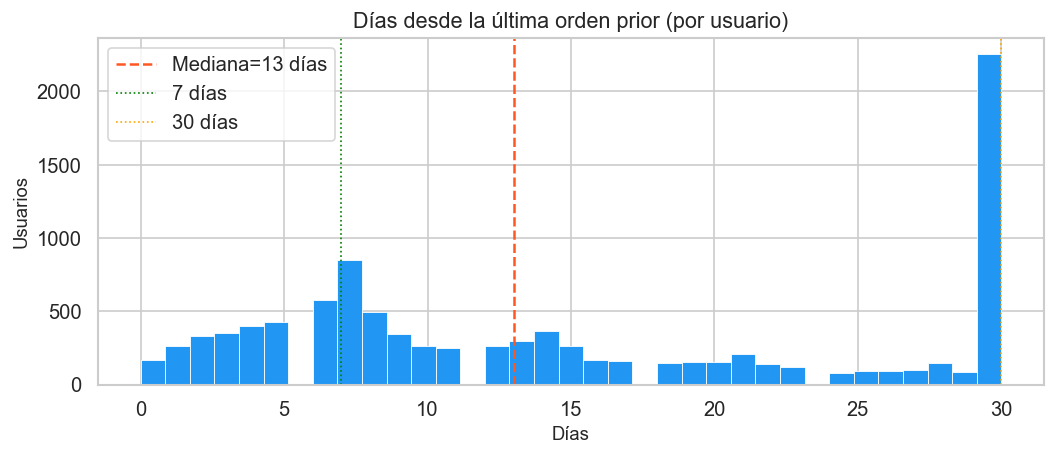

days_since_last_order — media=15.1 | mediana=13.0 | p95=30.0


In [7]:
# Días entre órdenes por usuario
days_last = (
    prior.sort_values('order_number')
    .groupby('user_key')['days_since_prior_order']
    .last()
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(days_last, bins=35, color=C_POS, edgecolor='white', linewidth=0.5)
ax.set_title('Días desde la última orden prior (por usuario)')
ax.set_xlabel('Días')
ax.set_ylabel('Usuarios')
ax.axvline(days_last.median(), color=C_ACCENT, ls='--', lw=1.5,
           label=f'Mediana={days_last.median():.0f} días')
ax.axvline(7,  color='green', ls=':', lw=1, label='7 días')
ax.axvline(30, color='orange', ls=':', lw=1, label='30 días')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_days_since_last_order.png', bbox_inches='tight')
plt.show()

print(f"days_since_last_order — media={days_last.mean():.1f} | mediana={days_last.median():.1f} | p95={days_last.quantile(0.95):.1f}")

## 4. Análisis de `dim_product`

In [8]:
print('dim_product — esquema:')
print(dim_product.dtypes)
print(f'\nColumnas: {dim_product.columns.tolist()}')
dim_product.head(3)

dim_product — esquema:
product_key         int64
product_name       object
aisle_name         object
department_name    object
dtype: object

Columnas: ['product_key', 'product_name', 'aisle_name', 'department_name']


,product_key,product_name,aisle_name,department_name
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks
1,2,All-Seasons Salt,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages


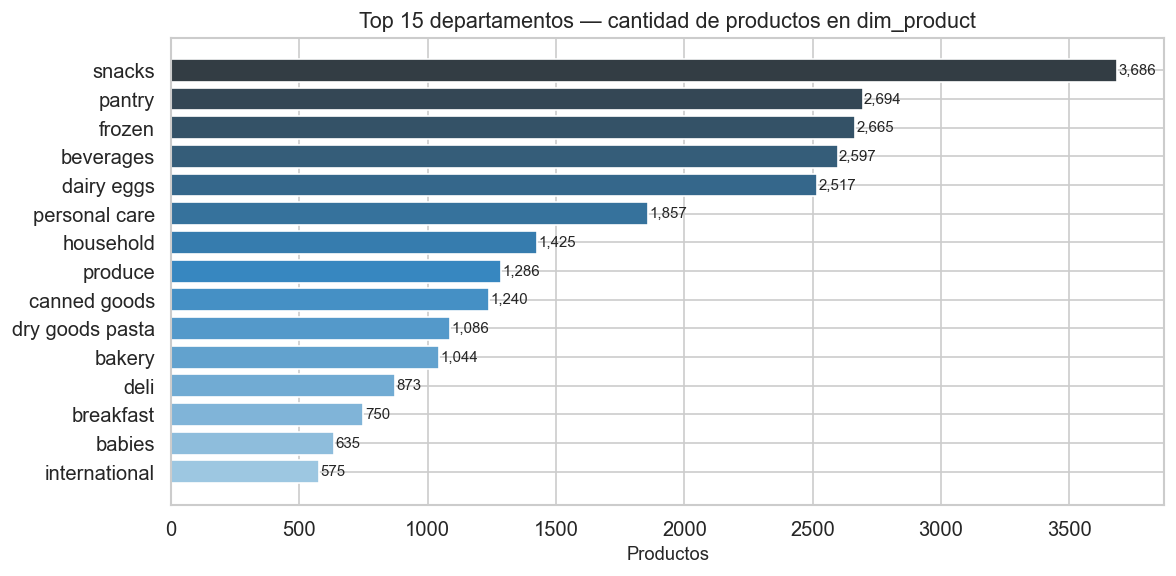

Departamentos únicos: 21
Aisles únicos: 134


In [9]:
# Top 15 departamentos por número de productos
if 'department_name' in dim_product.columns:
    dept_counts = dim_product['department_name'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(dept_counts.index[::-1], dept_counts.values[::-1],
                   color=sns.color_palette('Blues_d', len(dept_counts)))
    ax.set_title('Top 15 departamentos — cantidad de productos en dim_product')
    ax.set_xlabel('Productos')
    for bar in bars:
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_products_per_department.png', bbox_inches='tight')
    plt.show()
    print(f"Departamentos únicos: {dim_product['department_name'].nunique()}")
    print(f"Aisles únicos: {dim_product['aisle_name'].nunique() if 'aisle_name' in dim_product.columns else 'N/A'}")
else:
    print('department_name no disponible en dim_product — revisar ETL')

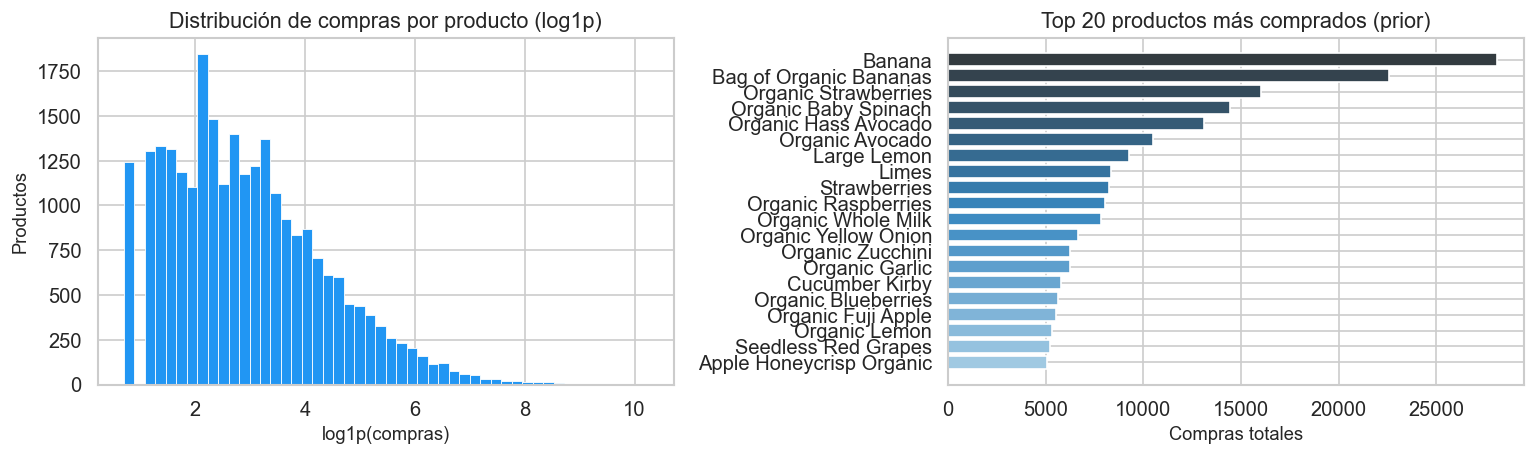

Productos con >=50 compras: 22.9% (filtro ETL aplicado)
Compras por producto — media=74 | mediana=14 | p99=933


In [10]:
# Popularidad de productos en prior: compras totales por producto
prod_purchases = (
    prior.groupby('product_key')['order_key']
    .count()
    .reset_index(name='total_purchases')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución (log scale)
axes[0].hist(np.log1p(prod_purchases['total_purchases']), bins=50,
             color=C_POS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de compras por producto (log1p)')
axes[0].set_xlabel('log1p(compras)')
axes[0].set_ylabel('Productos')

# Top 20 productos más comprados
top20 = prod_purchases.nlargest(20, 'total_purchases')
top20 = top20.merge(dim_product[['product_key', 'product_name']].drop_duplicates(),
                    on='product_key', how='left')
top20['label_short'] = top20['product_name'].str[:30] if 'product_name' in top20.columns else top20['product_key'].astype(str)
axes[1].barh(top20['label_short'][::-1], top20['total_purchases'][::-1],
             color=sns.color_palette('Blues_d', 20))
axes[1].set_title('Top 20 productos más comprados (prior)')
axes[1].set_xlabel('Compras totales')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_product_popularity.png', bbox_inches='tight')
plt.show()

pct_50plus = (prod_purchases['total_purchases'] >= 50).mean() * 100
print(f"Productos con >=50 compras: {pct_50plus:.1f}% (filtro ETL aplicado)")
print(f"Compras por producto — media={prod_purchases['total_purchases'].mean():.0f} | "
      f"mediana={prod_purchases['total_purchases'].median():.0f} | "
      f"p99={prod_purchases['total_purchases'].quantile(0.99):.0f}")

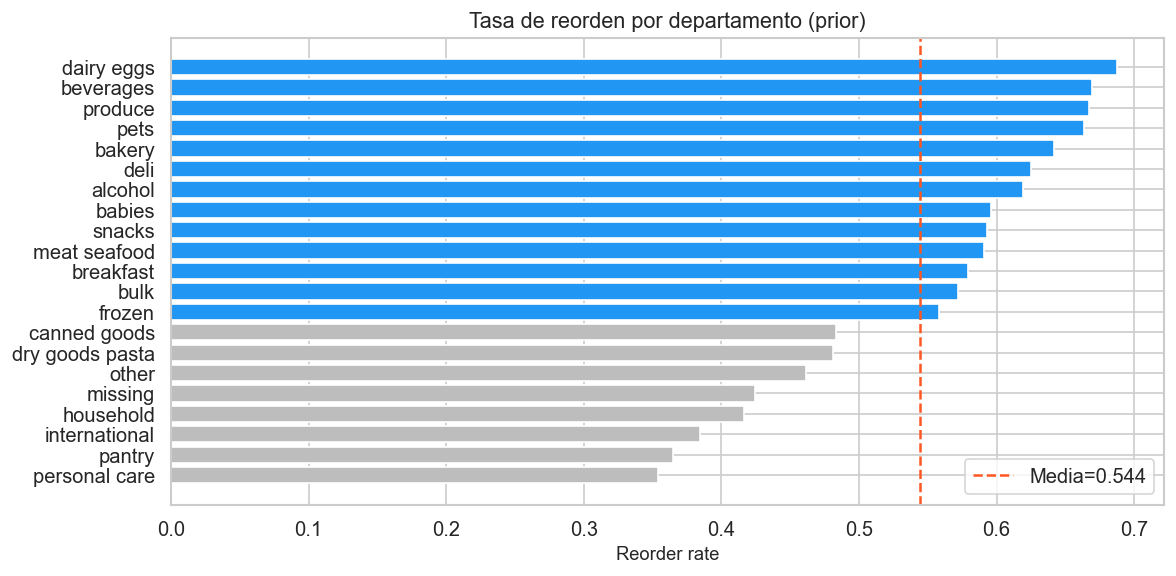

In [11]:
# Tasa de reorden global por departamento
if 'department_name' in dim_product.columns:
    prior_dept = prior.merge(
        dim_product[['product_key', 'department_name']].drop_duplicates(),
        on='product_key', how='left'
    )
    dept_reorder = (
        prior_dept.groupby('department_name')['reordered']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [C_POS if v >= dept_reorder['reordered'].mean() else C_NEG
              for v in dept_reorder['reordered']]
    ax.barh(dept_reorder['department_name'][::-1],
            dept_reorder['reordered'][::-1], color=colors[::-1])
    ax.axvline(dept_reorder['reordered'].mean(), color=C_ACCENT, ls='--', lw=1.5,
               label=f'Media={dept_reorder["reordered"].mean():.3f}')
    ax.set_title('Tasa de reorden por departamento (prior)')
    ax.set_xlabel('Reorder rate')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_reorder_rate_by_dept.png', bbox_inches='tight')
    plt.show()

## 5. Análisis de `fact_order_products`

In [12]:
print('fact_order_products — esquema:')
print(fact.dtypes)
print(f'\nNulos por columna:')
print(fact.isnull().sum())
print(f'\nDistribución de eval_set:')
print(fact['get_eval'].value_counts())

fact_order_products — esquema:
order_key                   int64
user_key                    int64
product_key                 int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
add_to_cart_order           int64
reordered                   int64
order_number                int64
get_eval                   object
dtype: object

Nulos por columna:
order_key                      0
user_key                       0
product_key                    0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    100852
add_to_cart_order              0
reordered                      0
order_number                   0
get_eval                       0
dtype: int64

Distribución de eval_set:
get_eval
prior    1894403
train     105242
Name: count, dtype: int64


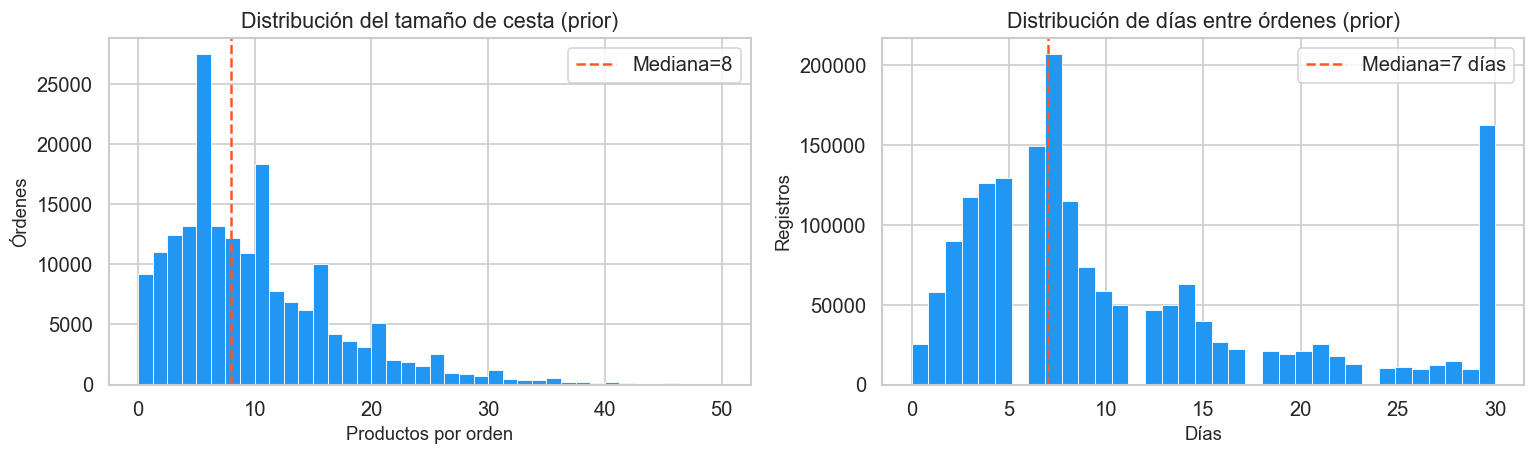

Tamaño de cesta — media=10.0 | mediana=8 | p95=25
Días entre órdenes — media=10.8 | mediana=7 | p95=30


In [13]:
# Tamaño de cesta por orden
basket_size = (
    prior.groupby('order_key')['product_key']
    .count()
    .reset_index(name='basket_size')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma basket size
axes[0].hist(basket_size['basket_size'], bins=40, range=(0, 50),
             color=C_POS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución del tamaño de cesta (prior)')
axes[0].set_xlabel('Productos por orden')
axes[0].set_ylabel('Órdenes')
axes[0].axvline(basket_size['basket_size'].median(), color=C_ACCENT, ls='--', lw=1.5,
                label=f'Mediana={basket_size["basket_size"].median():.0f}')
axes[0].legend()

# Días entre órdenes (toda la tabla prior)
days_dist = prior['days_since_prior_order'].dropna()
axes[1].hist(days_dist, bins=35, color=C_POS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución de días entre órdenes (prior)')
axes[1].set_xlabel('Días')
axes[1].set_ylabel('Registros')
axes[1].axvline(days_dist.median(), color=C_ACCENT, ls='--', lw=1.5,
                label=f'Mediana={days_dist.median():.0f} días')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_basket_days.png', bbox_inches='tight')
plt.show()

print(f"Tamaño de cesta — media={basket_size['basket_size'].mean():.1f} | "
      f"mediana={basket_size['basket_size'].median():.0f} | "
      f"p95={basket_size['basket_size'].quantile(0.95):.0f}")
print(f"Días entre órdenes — media={days_dist.mean():.1f} | "
      f"mediana={days_dist.median():.0f} | p95={days_dist.quantile(0.95):.0f}")

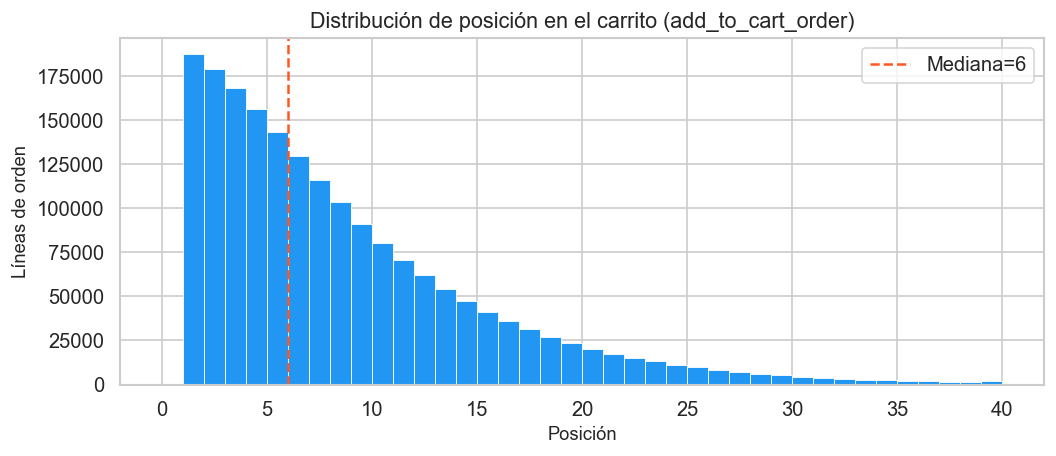

add_to_cart_order — media=8.3 | mediana=6


In [14]:
# Posición de add_to_cart_order
cart_pos = prior['add_to_cart_order'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cart_pos, bins=40, range=(0, 40), color=C_POS, edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de posición en el carrito (add_to_cart_order)')
ax.set_xlabel('Posición')
ax.set_ylabel('Líneas de orden')
ax.axvline(cart_pos.median(), color=C_ACCENT, ls='--', lw=1.5,
           label=f'Mediana={cart_pos.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_add_to_cart.png', bbox_inches='tight')
plt.show()
print(f"add_to_cart_order — media={cart_pos.mean():.1f} | mediana={cart_pos.median():.0f}")

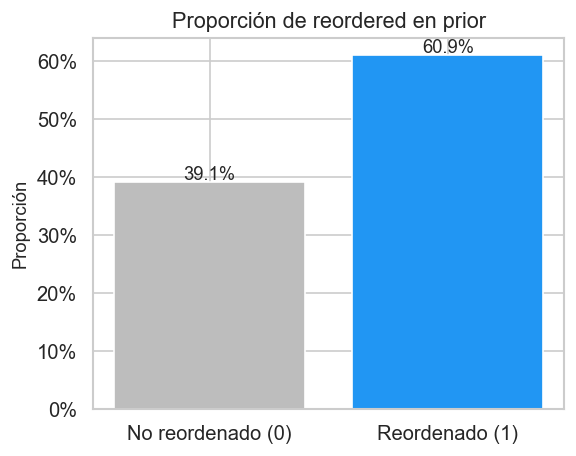

In [15]:
# Reordered global en prior
reorder_overall = prior['reordered'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No reordenado (0)', 'Reordenado (1)'],
       [reorder_overall.get(0, 0), reorder_overall.get(1, 0)],
       color=[C_NEG, C_POS])
ax.set_title('Proporción de reordered en prior')
ax.set_ylabel('Proporción')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate([reorder_overall.get(0, 0), reorder_overall.get(1, 0)]):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_reordered_overall.png', bbox_inches='tight')
plt.show()

## 6. Análisis del label (balance de clases)

In [16]:
# Construir pares (user_key, product_key) desde prior
# y cruzar contra train para obtener el label
pairs = (
    prior.groupby(['user_key', 'product_key'])
    .size()
    .reset_index(name='up_times_purchased')
)

train_pairs = (
    train[['user_key', 'product_key']]
    .drop_duplicates()
    .assign(label=1)
)

pairs_labeled = pairs.merge(train_pairs, on=['user_key', 'product_key'], how='left')
pairs_labeled['label'] = pairs_labeled['label'].fillna(0).astype(int)

n_pos   = (pairs_labeled['label'] == 1).sum()
n_neg   = (pairs_labeled['label'] == 0).sum()
n_total = len(pairs_labeled)
ratio   = n_neg / max(n_pos, 1)

print('Balance de clases del label:')
print(f'  label=1 (reordenó)    : {n_pos:>10,}  ({n_pos/n_total*100:.1f}%)')
print(f'  label=0 (no reordenó) : {n_neg:>10,}  ({n_neg/n_total*100:.1f}%)')
print(f'  Total pares u×p       : {n_total:>10,}')
print(f'  Ratio 0:1             : {ratio:.2f}:1')
print(f'  → scale_pos_weight recomendado para LightGBM: {ratio:.2f}')

Balance de clases del label:
  label=1 (reordenó)    :     68,276  (9.2%)
  label=0 (no reordenó) :    671,996  (90.8%)
  Total pares u×p       :    740,272
  Ratio 0:1             : 9.84:1
  → scale_pos_weight recomendado para LightGBM: 9.84


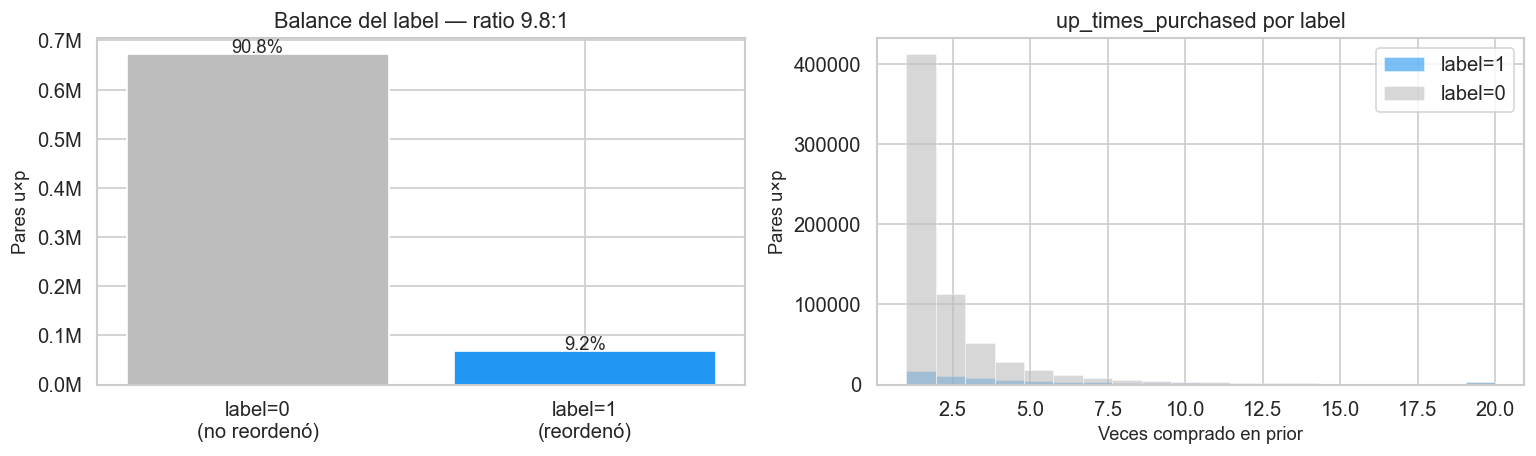

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico de desbalance
axes[0].bar(['label=0\n(no reordenó)', 'label=1\n(reordenó)'],
            [n_neg, n_pos], color=[C_NEG, C_POS])
axes[0].set_title(f'Balance del label — ratio {ratio:.1f}:1')
axes[0].set_ylabel('Pares u×p')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate([n_neg, n_pos]):
    axes[0].text(i, v + n_total * 0.005, f'{v/n_total:.1%}', ha='center', fontsize=11)

# Distribución de up_times_purchased por label
for lbl, color, name in [(1, C_POS, 'label=1'), (0, C_NEG, 'label=0')]:
    subset = pairs_labeled[pairs_labeled['label'] == lbl]['up_times_purchased']
    axes[1].hist(subset.clip(upper=20), bins=20, alpha=0.6,
                 color=color, label=name, edgecolor='white', linewidth=0.4)
axes[1].set_title('up_times_purchased por label')
axes[1].set_xlabel('Veces comprado en prior')
axes[1].set_ylabel('Pares u×p')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_label_balance.png', bbox_inches='tight')
plt.show()

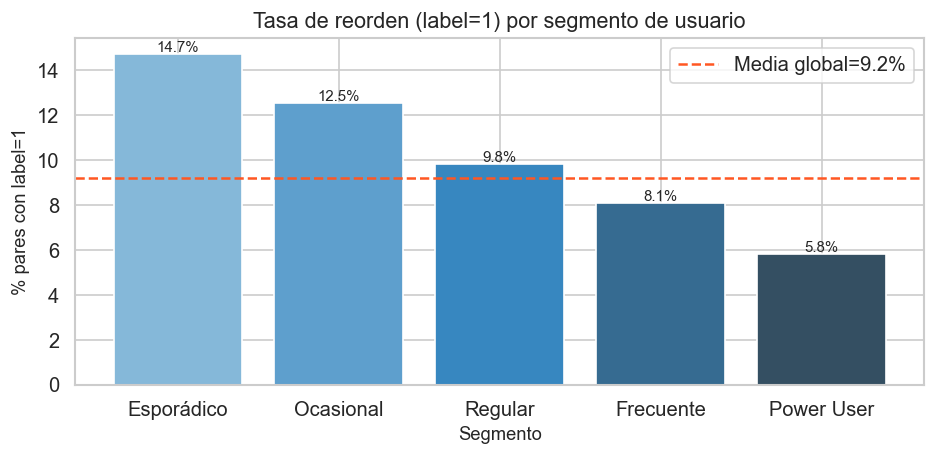

In [18]:
# Label=1 por segmento de usuario
SEGMENT_BINS  = [0, 5, 10, 20, 40, 9999]
SEGMENT_CODES = [1, 2, 3, 4, 5]
SEGMENT_NAMES_MAP = {1: 'Esporádico', 2: 'Ocasional', 3: 'Regular',
                     4: 'Frecuente', 5: 'Power User'}

user_orders_count = (
    prior.groupby('user_key')['order_key']
    .nunique()
    .reset_index(name='n_orders')
)
user_orders_count['segment'] = pd.cut(
    user_orders_count['n_orders'],
    bins=SEGMENT_BINS, labels=SEGMENT_CODES, right=True
).astype(float).fillna(0).astype(int).map(SEGMENT_NAMES_MAP)

pairs_seg = pairs_labeled.merge(user_orders_count[['user_key', 'segment']],
                                 on='user_key', how='left')
seg_label = (
    pairs_seg.groupby('segment')['label']
    .mean()
    .reindex(['Esporádico', 'Ocasional', 'Regular', 'Frecuente', 'Power User'])
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(seg_label.index, seg_label.values * 100,
              color=sns.color_palette('Blues_d', len(seg_label)))
ax.set_title('Tasa de reorden (label=1) por segmento de usuario')
ax.set_xlabel('Segmento')
ax.set_ylabel('% pares con label=1')
ax.axhline(pairs_labeled['label'].mean() * 100, color=C_ACCENT, ls='--', lw=1.5,
           label=f'Media global={pairs_labeled["label"].mean()*100:.1f}%')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_label_by_segment.png', bbox_inches='tight')
plt.show()

## 7. Resumen ejecutivo

In [19]:
print('=' * 65)
print('RESUMEN EDA — NeonDB Star Schema')
print('=' * 65)

print('\n📦 VOLUMEN DEL DATASET')
print(f'  Usuarios           : {len(dim_user):>10,}')
print(f'  Productos          : {len(dim_product):>10,}')
print(f'  Hechos de compra   : {len(fact):>10,}')
print(f'  Órdenes únicas     : {fact["order_key"].nunique():>10,}')
print(f'  Pares u×p (prior)  : {len(pairs_labeled):>10,}')

print('\n🛒 COMPORTAMIENTO DE COMPRA (PRIOR)')
print(f'  Órdenes/usuario    — media={orders_per_user["n_orders"].mean():.1f} | '
      f'mediana={orders_per_user["n_orders"].median():.0f}')
print(f'  Productos/orden    — media={basket_size["basket_size"].mean():.1f} | '
      f'mediana={basket_size["basket_size"].median():.0f}')
print(f'  Días entre órdenes — media={days_dist.mean():.1f} | '
      f'mediana={days_dist.median():.0f}')
print(f'  Reordered global   : {prior["reordered"].mean()*100:.1f}%')

print('\n🎯 LABEL (BALANCE DE CLASES)')
print(f'  label=1 (reordenó)    : {n_pos:>10,}  ({n_pos/n_total*100:.1f}%)')
print(f'  label=0 (no reordenó) : {n_neg:>10,}  ({n_neg/n_total*100:.1f}%)')
print(f'  Ratio 0:1             : {ratio:.2f}:1')
print(f'  → scale_pos_weight    : {ratio:.2f}')

print('\n✅ VALIDACIONES')
for name, ok in results.items():
    print(f'  {"✅" if ok else "❌"}  {name}')

print('\n📋 NOTAS PARA EL PIPELINE')
print(f'  - Dataset altamente desbalanceado (ratio {ratio:.1f}:1) → scale_pos_weight en LightGBM')
print(f'  - days_since_prior_order tiene NaN en la primera orden de cada usuario (esperado)')
print(f'  - up_avg_days_between_orders tendrá ~55% NaN (pares comprados 1 sola vez) → imputar con mediana')
print(f'  - Los Power Users tienen mayor tasa de reorden → segmento útil como feature')
print('=' * 65)

RESUMEN EDA — NeonDB Star Schema

📦 VOLUMEN DEL DATASET
  Usuarios           :     10,000
  Productos          :     26,686
  Hechos de compra   :  1,999,645
  Órdenes únicas     :    199,750
  Pares u×p (prior)  :    740,272

🛒 COMPORTAMIENTO DE COMPRA (PRIOR)
  Órdenes/usuario    — media=19.0 | mediana=13
  Productos/orden    — media=10.0 | mediana=8
  Días entre órdenes — media=10.8 | mediana=7
  Reordered global   : 60.9%

🎯 LABEL (BALANCE DE CLASES)
  label=1 (reordenó)    :     68,276  (9.2%)
  label=0 (no reordenó) :    671,996  (90.8%)
  Ratio 0:1             : 9.84:1
  → scale_pos_weight    : 9.84

✅ VALIDACIONES
  ✅  V-1: dim_user filas = 10.000
  ✅  V-2: dim_product filas = 26.686
  ✅  V-3: fact_order_products filas = 1.999.645
  ✅  V-4: Sin registros eval_set=test
  ✅  V-5: Sin usuarios huérfanos en fact
  ✅  V-6: Sin productos huérfanos en fact
  ✅  V-7: Usuarios con prior Y train >= 9.989
  ✅  V-8: Órdenes únicas ≈ 199.750

📋 NOTAS PARA EL PIPELINE
  - Dataset altamente d